# Statistical Analysis: Fixed Effects Panel Regression
## Industrialization vs Decarbonization: EU-6 Panel Analysis (2010-2024)

**Phase 3, Milestone 3.1: Statistical Analysis (Part 2)**

This notebook implements the econometric analysis to test the three research hypotheses:

1. **Goal 1: Quantify Regulatory Drag** - Does carbon pricing reduce industrial output?
2. **Goal 2: Test Porter Hypothesis** - Does carbon pricing drive efficiency/innovation?
3. **Goal 3: Assess Valley of Death** - Is the 2021-2024 period uniquely harmful?

### Methodology:
- **Fixed Effects (FE) Panel Regression** to control for country-specific heterogeneity
- **Time Fixed Effects** to control for common shocks (e.g., COVID-19, energy crisis)
- **Lagged Variables** to test dynamic/delayed effects (Porter Hypothesis)
- **Robustness Checks** with alternative specifications

---

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Econometric libraries
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from linearmodels.panel import compare
from scipy import stats

# Plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
%matplotlib inline

# Output directory
OUTPUT_DIR = Path('../../output/figures')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
TABLES_DIR = Path('../../output/tables')
TABLES_DIR.mkdir(exist_ok=True, parents=True)

## 1. Load and Prepare Data for Panel Analysis

In [2]:
# Load panel dataset
DATA_PATH = Path('../../data/processed/panel_dataset.csv')
df = pd.read_csv(DATA_PATH)

# Set up MultiIndex for panel data analysis (entity: country, time: year)
df = df.set_index(['country_code', 'year'])
print(f"Panel structure: {df.index.get_level_values(0).nunique()} countries × {df.index.get_level_values(1).nunique()} years")
print(f"Total observations: {len(df)}")

Panel structure: 6 countries × 15 years
Total observations: 90


In [3]:
# Create additional variables for analysis
print("\nCreating additional analysis variables...")

# Log transformations (already exist, verify)
required_vars = ['ln_gva_industry', 'ln_carbon_price', 'ln_emissions']
for var in required_vars:
    if var not in df.columns:
        if 'gva_industry' in var:
            df['ln_gva_industry'] = np.log(df['gva_industry_meur'])
        elif 'carbon_price' in var:
            df['ln_carbon_price'] = np.log(df['carbon_price_eur_tonne'])
        elif 'emissions' in var:
            df['ln_emissions'] = np.log(df['total_ghg_mt_co2eq'])

# Interaction terms
df['carbon_x_crisis'] = df['carbon_price_eur_tonne'] * df['energy_crisis']
df['carbon_x_phase4'] = df['carbon_price_eur_tonne'] * df['ets_phase_4']
df['carbon_x_covid'] = df['carbon_price_eur_tonne'] * df['covid_period']

# Squared term for non-linearity
df['carbon_price_sq'] = df['carbon_price_eur_tonne'] ** 2
df['ln_carbon_price_sq'] = df['ln_carbon_price'] ** 2

print("✓ Log transformations verified")
print("✓ Interaction terms created (carbon × crisis, carbon × phase4)")
print("✓ Quadratic terms created for non-linearity tests")


Creating additional analysis variables...
✓ Log transformations verified
✓ Interaction terms created (carbon × crisis, carbon × phase4)
✓ Quadratic terms created for non-linearity tests


In [17]:
# Summary of key variables
analysis_vars = [
    'ln_gva_industry', 'ln_carbon_price', 'ln_emissions',
    'carbon_intensity_t_per_meur', 'carbon_cost_burden_pct',
    'free_allocation_ratio_pct', 'ppi_index_2015',
    'covid_period', 'energy_crisis', 'ets_phase_4'
]

print("\nDESCRIPTIVE STATISTICS - ANALYSIS VARIABLES")
print("="*70)
df[analysis_vars].describe().round(4)


DESCRIPTIVE STATISTICS - ANALYSIS VARIABLES


,ln_gva_industry,ln_carbon_price,ln_emissions,carbon_intensity_t_per_meur,carbon_cost_burden_pct,free_allocation_ratio_pct,ppi_index_2015,covid_period,energy_crisis,ets_phase_4
count,90.0000,90.0000,90.0000,90.0000,90.0000,90.0000,90.0000,90.0000,90.0000,90.0000
mean,12.2680,2.8109,5.9626,1970.4031,0.5699,79.0222,108.0822,0.1333,0.1333,0.2667
std,0.6704,1.0075,0.4679,869.6419,0.8864,15.8391,17.1807,0.3418,0.3418,0.4447
min,11.3414,1.4951,4.9698,948.2700,0.0000,50.0000,88.2000,0.0000,0.0000,0.0000
25%,11.6288,1.7851,5.7815,1426.0650,0.0400,68.0000,97.8500,0.0000,0.0000,0.0000
50%,12.2486,2.6617,5.9814,1709.9700,0.1200,79.0000,100.0000,0.0000,0.0000,0.0000
75%,12.5652,3.9761,6.1399,2036.9825,0.8875,89.5000,109.7750,0.0000,0.0000,1.0000
max,13.5200,4.4268,6.8544,4748.3400,4.3300,110.0000,152.3000,1.0000,1.0000,1.0000


## 2. Model Specification

### Base Model (Fixed Effects):

$$\ln(GVA_{it}) = \alpha_i + \beta_1 \ln(CarbonPrice_t) + \beta_2 X_{it} + \gamma_t + \epsilon_{it}$$

Where:
- $GVA_{it}$ = Industrial Gross Value Added for country $i$ in year $t$
- $\alpha_i$ = Country fixed effects (controls for time-invariant country characteristics)
- $CarbonPrice_t$ = EU ETS carbon price (same for all countries)
- $X_{it}$ = Control variables (PPI inflation, free allocation ratio, etc.)
- $\gamma_t$ = Year fixed effects (optional, controls for common shocks)
- $\epsilon_{it}$ = Error term

### Interpretation:
- $\beta_1$ is the **elasticity**: a 1% increase in carbon price leads to $\beta_1$% change in industrial output

## 3. Research Goal 1: Quantify Regulatory Drag

**Hypothesis:** High carbon prices cause statistically significant contraction in industrial output.

**Test:** Estimate the coefficient on carbon price in the industrial GVA equation.

In [4]:
# Prepare data for regression (drop missing values)
reg_vars = ['ln_gva_industry', 'ln_carbon_price', 'ppi_index_2015', 
            'free_allocation_ratio_pct', 'covid_period', 'energy_crisis']
reg_data = df[reg_vars].dropna()

print(f"Regression sample: {len(reg_data)} observations")
print(f"Countries: {reg_data.index.get_level_values(0).nunique()}")
print(f"Years: {reg_data.index.get_level_values(1).nunique()}")

Regression sample: 90 observations
Countries: 6
Years: 15


In [5]:
# Model 1: Simple FE - Carbon Price Effect on Industrial Output
print("\n" + "="*70)
print("MODEL 1: SIMPLE FIXED EFFECTS")
print("Dependent Variable: ln(Industrial GVA)")
print("="*70)

y = reg_data['ln_gva_industry']
X = reg_data[['ln_carbon_price']]
X = sm.add_constant(X)

model1 = PanelOLS(y, X, entity_effects=True)
results1 = model1.fit(cov_type='clustered', cluster_entity=True)
print(results1.summary)


MODEL 1: SIMPLE FIXED EFFECTS
Dependent Variable: ln(Industrial GVA)
                          PanelOLS Estimation Summary                           
Dep. Variable:        ln_gva_industry   R-squared:                        0.2639
Estimator:                   PanelOLS   R-squared (Between):              0.0000
No. Observations:                  90   R-squared (Within):               0.2639
Date:                Sat, Jan 31 2026   R-squared (Overall):              0.0026
Time:                        15:19:26   Log-likelihood                    130.67
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      29.753
Entities:                           6   P-value                           0.0000
Avg Obs:                       15.000   Distribution:                    F(1,83)
Min Obs:                       15.000                                           
Max Obs:                       15.000  

In [6]:
# Model 2: FE with Controls
print("\n" + "="*70)
print("MODEL 2: FIXED EFFECTS WITH CONTROLS")
print("Dependent Variable: ln(Industrial GVA)")
print("="*70)

X2 = reg_data[['ln_carbon_price', 'ppi_index_2015', 'free_allocation_ratio_pct']]
X2 = sm.add_constant(X2)

model2 = PanelOLS(y, X2, entity_effects=True)
results2 = model2.fit(cov_type='clustered', cluster_entity=True)
print(results2.summary)


MODEL 2: FIXED EFFECTS WITH CONTROLS
Dependent Variable: ln(Industrial GVA)
                          PanelOLS Estimation Summary                           
Dep. Variable:        ln_gva_industry   R-squared:                        0.4113
Estimator:                   PanelOLS   R-squared (Between):              0.0062
No. Observations:                  90   R-squared (Within):               0.4113
Date:                Sat, Jan 31 2026   R-squared (Overall):              0.0102
Time:                        15:19:29   Log-likelihood                    140.72
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      18.865
Entities:                           6   P-value                           0.0000
Avg Obs:                       15.000   Distribution:                    F(3,81)
Min Obs:                       15.000                                           
Max Obs:                       1

In [7]:
# Model 3: FE with Controls + Crisis Dummies
print("\n" + "="*70)
print("MODEL 3: FIXED EFFECTS WITH CRISIS DUMMIES")
print("Dependent Variable: ln(Industrial GVA)")
print("="*70)

X3 = reg_data[['ln_carbon_price', 'ppi_index_2015', 'free_allocation_ratio_pct', 
               'covid_period', 'energy_crisis']]
X3 = sm.add_constant(X3)

model3 = PanelOLS(y, X3, entity_effects=True)
results3 = model3.fit(cov_type='clustered', cluster_entity=True)
print(results3.summary)


MODEL 3: FIXED EFFECTS WITH CRISIS DUMMIES
Dependent Variable: ln(Industrial GVA)
                          PanelOLS Estimation Summary                           
Dep. Variable:        ln_gva_industry   R-squared:                        0.4271
Estimator:                   PanelOLS   R-squared (Between):              0.0050
No. Observations:                  90   R-squared (Within):               0.4271
Date:                Sat, Jan 31 2026   R-squared (Overall):              0.0091
Time:                        15:19:31   Log-likelihood                    141.94
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      11.777
Entities:                           6   P-value                           0.0000
Avg Obs:                       15.000   Distribution:                    F(5,79)
Min Obs:                       15.000                                           
Max Obs:                  

In [8]:
# Model 4: Two-Way Fixed Effects (Entity + Time)
print("\n" + "="*70)
print("MODEL 4: TWO-WAY FIXED EFFECTS")
print("Dependent Variable: ln(Industrial GVA)")
print("="*70)

# Note: With time FE, we can't include variables that only vary by time (like carbon price)
# So we use a different specification
X4 = reg_data[['ppi_index_2015', 'free_allocation_ratio_pct']]
X4 = sm.add_constant(X4)

model4 = PanelOLS(y, X4, entity_effects=True, time_effects=True)
results4 = model4.fit(cov_type='clustered', cluster_entity=True)
print(results4.summary)
print("\nNote: Carbon price absorbed by time fixed effects (varies only by time, not entity)")


MODEL 4: TWO-WAY FIXED EFFECTS
Dependent Variable: ln(Industrial GVA)
                          PanelOLS Estimation Summary                           
Dep. Variable:        ln_gva_industry   R-squared:                        0.5002
Estimator:                   PanelOLS   R-squared (Between):              0.0207
No. Observations:                  90   R-squared (Within):              -19.643
Date:                Sat, Jan 31 2026   R-squared (Overall):             -0.1722
Time:                        15:19:34   Log-likelihood                    181.63
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      34.034
Entities:                           6   P-value                           0.0000
Avg Obs:                       15.000   Distribution:                    F(2,68)
Min Obs:                       15.000                                           
Max Obs:                       15.000 

## 4. Research Goal 2: Test Porter Hypothesis (Innovation/Efficiency)

**Hypothesis:** Carbon pricing leads to efficiency improvements (lower carbon intensity) with a lag.

**Test:** Estimate the effect of lagged carbon prices on carbon intensity.

In [9]:
# Model 5: Porter Hypothesis - Effect on Carbon Intensity
print("\n" + "="*70)
print("MODEL 5: PORTER HYPOTHESIS - CARBON INTENSITY")
print("Dependent Variable: Carbon Intensity (t CO2/M€)")
print("="*70)

# Prepare data with lagged variables
porter_vars = ['carbon_intensity_t_per_meur', 'ln_carbon_price', 'carbon_price_lag1', 
               'carbon_price_lag2', 'ppi_index_2015']
porter_data = df[porter_vars].dropna()

print(f"Sample size: {len(porter_data)} (reduced due to lags)")

y5 = porter_data['carbon_intensity_t_per_meur']
X5 = porter_data[['ln_carbon_price', 'ppi_index_2015']]
X5 = sm.add_constant(X5)

model5 = PanelOLS(y5, X5, entity_effects=True)
results5 = model5.fit(cov_type='clustered', cluster_entity=True)
print(results5.summary)


MODEL 5: PORTER HYPOTHESIS - CARBON INTENSITY
Dependent Variable: Carbon Intensity (t CO2/M€)
Sample size: 78 (reduced due to lags)
                               PanelOLS Estimation Summary                               
Dep. Variable:     carbon_intensity_t_per_meur   R-squared:                        0.6802
Estimator:                            PanelOLS   R-squared (Between):             -0.0116
No. Observations:                           78   R-squared (Within):               0.6802
Date:                         Sat, Jan 31 2026   R-squared (Overall):              0.0531
Time:                                 15:19:37   Log-likelihood                   -497.02
Cov. Estimator:                      Clustered                                           
                                                 F-statistic:                      74.443
Entities:                                    6   P-value                           0.0000
Avg Obs:                                13.000   Distribu

In [10]:
# Model 6: Porter Hypothesis with Lagged Effects
print("\n" + "="*70)
print("MODEL 6: PORTER HYPOTHESIS WITH LAGGED CARBON PRICE")
print("Dependent Variable: Carbon Intensity (t CO2/M€)")
print("="*70)

# Log transform lags
porter_data['ln_carbon_price_lag1'] = np.log(porter_data['carbon_price_lag1'])
porter_data['ln_carbon_price_lag2'] = np.log(porter_data['carbon_price_lag2'])

y6 = porter_data['carbon_intensity_t_per_meur']
X6 = porter_data[['ln_carbon_price', 'ln_carbon_price_lag1', 'ln_carbon_price_lag2', 'ppi_index_2015']]
X6 = sm.add_constant(X6)

model6 = PanelOLS(y6, X6, entity_effects=True)
results6 = model6.fit(cov_type='clustered', cluster_entity=True)
print(results6.summary)


MODEL 6: PORTER HYPOTHESIS WITH LAGGED CARBON PRICE
Dependent Variable: Carbon Intensity (t CO2/M€)
                               PanelOLS Estimation Summary                               
Dep. Variable:     carbon_intensity_t_per_meur   R-squared:                        0.6835
Estimator:                            PanelOLS   R-squared (Between):             -0.0143
No. Observations:                           78   R-squared (Within):               0.6835
Date:                         Sat, Jan 31 2026   R-squared (Overall):              0.0509
Time:                                 15:19:41   Log-likelihood                   -496.62
Cov. Estimator:                      Clustered                                           
                                                 F-statistic:                      36.713
Entities:                                    6   P-value                           0.0000
Avg Obs:                                13.000   Distribution:                    F(4,68)

In [11]:
# Model 7: Effect on Emissions (Direct Decarbonization)
print("\n" + "="*70)
print("MODEL 7: DIRECT DECARBONIZATION EFFECT")
print("Dependent Variable: ln(GHG Emissions)")
print("="*70)

emissions_vars = ['ln_emissions', 'ln_carbon_price', 'ln_gva_industry', 
                  'ppi_index_2015', 'covid_period']
emissions_data = df[emissions_vars].dropna()

y7 = emissions_data['ln_emissions']
X7 = emissions_data[['ln_carbon_price', 'ln_gva_industry', 'ppi_index_2015', 'covid_period']]
X7 = sm.add_constant(X7)

model7 = PanelOLS(y7, X7, entity_effects=True)
results7 = model7.fit(cov_type='clustered', cluster_entity=True)
print(results7.summary)


MODEL 7: DIRECT DECARBONIZATION EFFECT
Dependent Variable: ln(GHG Emissions)
                          PanelOLS Estimation Summary                           
Dep. Variable:           ln_emissions   R-squared:                        0.7152
Estimator:                   PanelOLS   R-squared (Between):              0.6527
No. Observations:                  90   R-squared (Within):               0.7152
Date:                Sat, Jan 31 2026   R-squared (Overall):              0.6553
Time:                        15:19:44   Log-likelihood                    140.94
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      50.218
Entities:                           6   P-value                           0.0000
Avg Obs:                       15.000   Distribution:                    F(4,80)
Min Obs:                       15.000                                           
Max Obs:                       

## 5. Research Goal 3: Valley of Death (2021-2024)

**Hypothesis:** The combination of high carbon prices AND energy crisis creates a "double burden" that is uniquely harmful.

**Test:** Interaction term between carbon price and energy crisis period.

In [12]:
# Model 8: Valley of Death - Interaction Effects
print("\n" + "="*70)
print("MODEL 8: VALLEY OF DEATH - INTERACTION EFFECTS")
print("Dependent Variable: ln(Industrial GVA)")
print("="*70)

# Prepare interaction data
valley_vars = ['ln_gva_industry', 'ln_carbon_price', 'carbon_x_crisis', 'carbon_x_phase4',
               'ppi_index_2015', 'covid_period', 'energy_crisis', 'ets_phase_4']
valley_data = df[valley_vars].dropna()

y8 = valley_data['ln_gva_industry']
X8 = valley_data[['ln_carbon_price', 'energy_crisis', 'carbon_x_crisis', 'ppi_index_2015', 'covid_period']]
X8 = sm.add_constant(X8)

model8 = PanelOLS(y8, X8, entity_effects=True)
results8 = model8.fit(cov_type='clustered', cluster_entity=True)
print(results8.summary)


MODEL 8: VALLEY OF DEATH - INTERACTION EFFECTS
Dependent Variable: ln(Industrial GVA)
                          PanelOLS Estimation Summary                           
Dep. Variable:        ln_gva_industry   R-squared:                        0.3814
Estimator:                   PanelOLS   R-squared (Between):             -0.0085
No. Observations:                  90   R-squared (Within):               0.3814
Date:                Sat, Jan 31 2026   R-squared (Overall):             -0.0046
Time:                        15:19:48   Log-likelihood                    138.49
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      9.7415
Entities:                           6   P-value                           0.0000
Avg Obs:                       15.000   Distribution:                    F(5,79)
Min Obs:                       15.000                                           
Max Obs:              

In [13]:
# Model 9: Phase 4 Specific Effects
print("\n" + "="*70)
print("MODEL 9: PHASE 4 SPECIFIC EFFECTS")
print("Dependent Variable: ln(Industrial GVA)")
print("="*70)

y9 = valley_data['ln_gva_industry']
X9 = valley_data[['ln_carbon_price', 'ets_phase_4', 'carbon_x_phase4', 'ppi_index_2015', 'covid_period']]
X9 = sm.add_constant(X9)

model9 = PanelOLS(y9, X9, entity_effects=True)
results9 = model9.fit(cov_type='clustered', cluster_entity=True)
print(results9.summary)


MODEL 9: PHASE 4 SPECIFIC EFFECTS
Dependent Variable: ln(Industrial GVA)
                          PanelOLS Estimation Summary                           
Dep. Variable:        ln_gva_industry   R-squared:                        0.4729
Estimator:                   PanelOLS   R-squared (Between):             -0.0166
No. Observations:                  90   R-squared (Within):               0.4729
Date:                Sat, Jan 31 2026   R-squared (Overall):             -0.0118
Time:                        15:19:53   Log-likelihood                    145.70
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      14.178
Entities:                           6   P-value                           0.0000
Avg Obs:                       15.000   Distribution:                    F(5,79)
Min Obs:                       15.000                                           
Max Obs:                       15.0

## 6. Robustness Checks

In [14]:
# Robustness 1: Random Effects for comparison
print("\n" + "="*70)
print("ROBUSTNESS CHECK 1: RANDOM EFFECTS MODEL")
print("="*70)

# Note: Random Effects requires neffects > nvar for estimation
# With 6 countries, we need fewer than 6 parameters
# Using a simplified specification

y_re = reg_data['ln_gva_industry']
X_re = reg_data[['ln_carbon_price', 'ppi_index_2015', 'covid_period']]
X_re = sm.add_constant(X_re)

print(f"Note: Using simplified specification (4 params) for 6 countries")
print(f"Variables: constant, ln_carbon_price, ppi_index_2015, covid_period\n")

try:
    model_re = RandomEffects(y_re, X_re)
    results_re = model_re.fit(cov_type='clustered', cluster_entity=True)
    print(results_re.summary)
except Exception as e:
    print(f"Random Effects estimation failed: {e}")
    print("This can occur with small panels (few entities relative to parameters)")
    # Fallback: use basic RE without clustering
    try:
        model_re = RandomEffects(y_re, X_re)
        results_re = model_re.fit()
        print("\nFallback: Random Effects without clustered SEs:")
        print(results_re.summary)
    except Exception as e2:
        print(f"Fallback also failed: {e2}")
        results_re = None


ROBUSTNESS CHECK 1: RANDOM EFFECTS MODEL
Note: Using simplified specification (4 params) for 6 countries
Variables: constant, ln_carbon_price, ppi_index_2015, covid_period

                        RandomEffects Estimation Summary                        
Dep. Variable:        ln_gva_industry   R-squared:                        0.3357
Estimator:              RandomEffects   R-squared (Between):             -0.0064
No. Observations:                  90   R-squared (Within):               0.3467
Date:                Sat, Jan 31 2026   R-squared (Overall):             -0.0030
Time:                        15:19:55   Log-likelihood                    133.86
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      14.487
Entities:                           6   P-value                           0.0000
Avg Obs:                       15.000   Distribution:                    F(3,86)
Min Obs:        

In [15]:
# Robustness 2: Pooled OLS for comparison
print("\n" + "="*70)
print("ROBUSTNESS CHECK 2: POOLED OLS (No Fixed Effects)")
print("="*70)

# Use same specification as Random Effects for comparability
X_pooled = reg_data[['ln_carbon_price', 'ppi_index_2015', 'covid_period']]
X_pooled = sm.add_constant(X_pooled)

model_pooled = PooledOLS(y_re, X_pooled)
results_pooled = model_pooled.fit(cov_type='clustered', cluster_entity=True)
print(results_pooled.summary)


ROBUSTNESS CHECK 2: POOLED OLS (No Fixed Effects)
                          PooledOLS Estimation Summary                          
Dep. Variable:        ln_gva_industry   R-squared:                        0.0101
Estimator:                  PooledOLS   R-squared (Between):              0.0196
No. Observations:                  90   R-squared (Within):              -0.9498
Date:                Sat, Jan 31 2026   R-squared (Overall):              0.0101
Time:                        15:19:57   Log-likelihood                   -90.761
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.2924
Entities:                           6   P-value                           0.8308
Avg Obs:                       15.000   Distribution:                    F(3,86)
Min Obs:                       15.000                                           
Max Obs:                       15.000   F-statistic (robus

In [16]:
# Robustness 3: Non-linearity test (quadratic carbon price)
print("\n" + "="*70)
print("ROBUSTNESS CHECK 3: NON-LINEARITY TEST")
print("="*70)

nonlin_data = df[['ln_gva_industry', 'ln_carbon_price', 'ln_carbon_price_sq', 
                  'ppi_index_2015', 'covid_period', 'energy_crisis']].dropna()

y_nl = nonlin_data['ln_gva_industry']
X_nl = nonlin_data[['ln_carbon_price', 'ln_carbon_price_sq', 'ppi_index_2015', 
                    'covid_period', 'energy_crisis']]
X_nl = sm.add_constant(X_nl)

model_nl = PanelOLS(y_nl, X_nl, entity_effects=True)
results_nl = model_nl.fit(cov_type='clustered', cluster_entity=True)
print(results_nl.summary)


ROBUSTNESS CHECK 3: NON-LINEARITY TEST
                          PanelOLS Estimation Summary                           
Dep. Variable:        ln_gva_industry   R-squared:                        0.4353
Estimator:                   PanelOLS   R-squared (Between):             -0.0160
No. Observations:                  90   R-squared (Within):               0.4353
Date:                Sat, Jan 31 2026   R-squared (Overall):             -0.0116
Time:                        15:19:59   Log-likelihood                    142.60
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      12.182
Entities:                           6   P-value                           0.0000
Avg Obs:                       15.000   Distribution:                    F(5,79)
Min Obs:                       15.000                                           
Max Obs:                       15.000   F-statistic (robust):        

In [17]:
# Robustness 4: Exclude COVID period
print("\n" + "="*70)
print("ROBUSTNESS CHECK 4: EXCLUDING COVID PERIOD (2020-2021)")
print("="*70)

no_covid_data = reg_data[reg_data.index.get_level_values(1).isin([2020, 2021]) == False]
print(f"Sample size: {len(no_covid_data)} (after excluding 2020-2021)")

y_nc = no_covid_data['ln_gva_industry']
X_nc = no_covid_data[['ln_carbon_price', 'ppi_index_2015', 'free_allocation_ratio_pct', 'energy_crisis']]
X_nc = sm.add_constant(X_nc)

model_nc = PanelOLS(y_nc, X_nc, entity_effects=True)
results_nc = model_nc.fit(cov_type='clustered', cluster_entity=True)
print(results_nc.summary)


ROBUSTNESS CHECK 4: EXCLUDING COVID PERIOD (2020-2021)
Sample size: 78 (after excluding 2020-2021)
                          PanelOLS Estimation Summary                           
Dep. Variable:        ln_gva_industry   R-squared:                        0.4418
Estimator:                   PanelOLS   R-squared (Between):              0.0063
No. Observations:                  78   R-squared (Within):               0.4418
Date:                Sat, Jan 31 2026   R-squared (Overall):              0.0106
Time:                        15:20:02   Log-likelihood                    122.66
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      13.454
Entities:                           6   P-value                           0.0000
Avg Obs:                       13.000   Distribution:                    F(4,68)
Min Obs:                       13.000                                           
Max Obs: 

## 7. Results Comparison Table

In [18]:
# Create comparison table
print("\n" + "="*80)
print("REGRESSION RESULTS SUMMARY")
print("="*80)

# Build comparison dict, only including models that succeeded
comparison_dict = {
    'Model 1: Simple FE': results1,
    'Model 2: FE + Controls': results2,
    'Model 3: FE + Crisis': results3,
    'Model 8: Interactions': results8,
    'Pooled OLS': results_pooled
}

# Add Random Effects only if it succeeded
if results_re is not None:
    comparison_dict['Random Effects'] = results_re

comparison = compare(comparison_dict)
print(comparison.summary)


REGRESSION RESULTS SUMMARY
                                                                      Model Comparison                                                                     
                               Model 1: Simple FE Model 2: FE + Controls Model 3: FE + Crisis Model 8: Interactions          Pooled OLS      Random Effects
-----------------------------------------------------------------------------------------------------------------------------------------------------------
Dep. Variable                     ln_gva_industry        ln_gva_industry      ln_gva_industry       ln_gva_industry     ln_gva_industry     ln_gva_industry
Estimator                                PanelOLS               PanelOLS             PanelOLS              PanelOLS           PooledOLS       RandomEffects
No. Observations                               90                     90                   90                    90                  90                  90
Cov. Est.                           

In [19]:
# Create custom summary table
print("\n" + "="*80)
print("TABLE 2: MAIN REGRESSION RESULTS")
print("Dependent Variable: ln(Industrial GVA)")
print("="*80)

results_table = pd.DataFrame({
    'Variable': ['ln(Carbon Price)', 'PPI Index', 'Free Allocation %', 
                 'COVID Period', 'Energy Crisis', 'Carbon × Crisis',
                 'Constant', '', 'R² (within)', 'Observations', 'Countries'],
    'Model 1': [f"{results1.params.get('ln_carbon_price', ''):.4f}" if 'ln_carbon_price' in results1.params else '',
               '', '', '', '', '',
               f"{results1.params.get('const', ''):.4f}" if 'const' in results1.params else '',
               '', f"{results1.rsquared_within:.4f}", str(results1.nobs), '6'],
    'Model 2': [f"{results2.params.get('ln_carbon_price', ''):.4f}" if 'ln_carbon_price' in results2.params else '',
               f"{results2.params.get('ppi_index_2015', ''):.4f}" if 'ppi_index_2015' in results2.params else '',
               f"{results2.params.get('free_allocation_ratio_pct', ''):.4f}" if 'free_allocation_ratio_pct' in results2.params else '',
               '', '', '',
               f"{results2.params.get('const', ''):.4f}" if 'const' in results2.params else '',
               '', f"{results2.rsquared_within:.4f}", str(results2.nobs), '6'],
    'Model 3': [f"{results3.params.get('ln_carbon_price', ''):.4f}" if 'ln_carbon_price' in results3.params else '',
               f"{results3.params.get('ppi_index_2015', ''):.4f}" if 'ppi_index_2015' in results3.params else '',
               f"{results3.params.get('free_allocation_ratio_pct', ''):.4f}" if 'free_allocation_ratio_pct' in results3.params else '',
               f"{results3.params.get('covid_period', ''):.4f}" if 'covid_period' in results3.params else '',
               f"{results3.params.get('energy_crisis', ''):.4f}" if 'energy_crisis' in results3.params else '',
               '',
               f"{results3.params.get('const', ''):.4f}" if 'const' in results3.params else '',
               '', f"{results3.rsquared_within:.4f}", str(results3.nobs), '6'],
    'Model 8': [f"{results8.params.get('ln_carbon_price', ''):.4f}" if 'ln_carbon_price' in results8.params else '',
               f"{results8.params.get('ppi_index_2015', ''):.4f}" if 'ppi_index_2015' in results8.params else '',
               '',
               f"{results8.params.get('covid_period', ''):.4f}" if 'covid_period' in results8.params else '',
               f"{results8.params.get('energy_crisis', ''):.4f}" if 'energy_crisis' in results8.params else '',
               f"{results8.params.get('carbon_x_crisis', ''):.4f}" if 'carbon_x_crisis' in results8.params else '',
               f"{results8.params.get('const', ''):.4f}" if 'const' in results8.params else '',
               '', f"{results8.rsquared_within:.4f}", str(results8.nobs), '6']
})

print(results_table.to_string(index=False))

# Save table
results_table.to_csv(TABLES_DIR / 'table2_regression_results.csv', index=False)
print(f"\n✓ Saved: {TABLES_DIR / 'table2_regression_results.csv'}")


TABLE 2: MAIN REGRESSION RESULTS
Dependent Variable: ln(Industrial GVA)
         Variable Model 1 Model 2 Model 3 Model 8
 ln(Carbon Price)  0.0339  0.0016  0.0075  0.0038
        PPI Index          0.0006  0.0010  0.0029
Free Allocation %         -0.0020 -0.0020        
     COVID Period                 -0.0165  0.0101
    Energy Crisis                 -0.0371  0.2080
  Carbon × Crisis                         -0.0032
         Constant 12.1728 12.3567 12.3056 11.9454
                                                 
      R² (within)  0.2639  0.4113  0.4271  0.3814
     Observations      90      90      90      90
        Countries       6       6       6       6

✓ Saved: ../../output/tables/table2_regression_results.csv


## 8. Coefficient Visualization

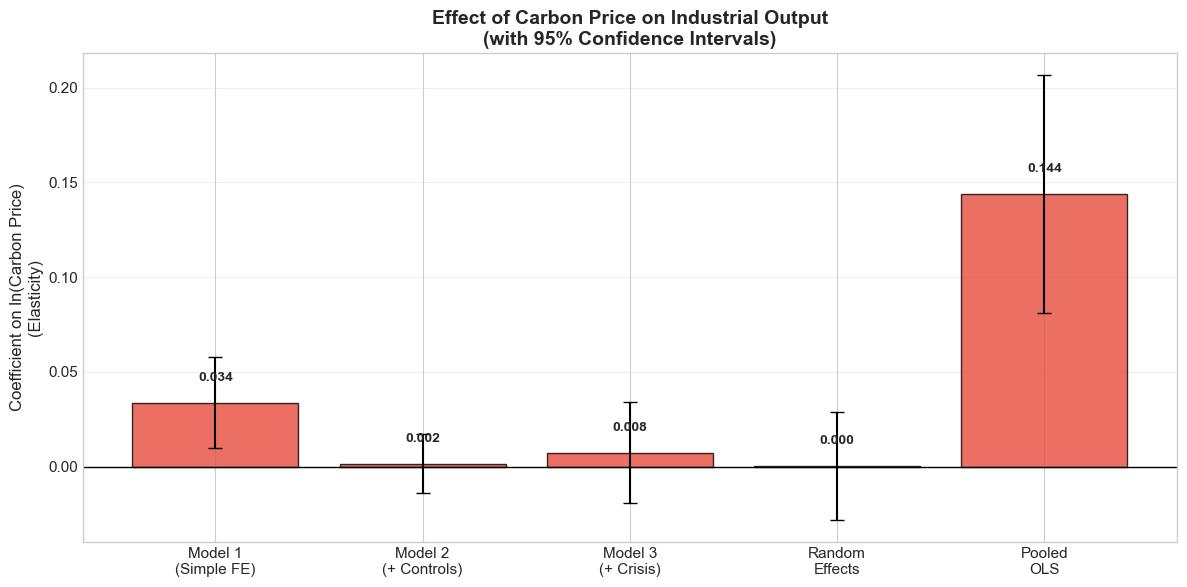


✓ Saved: ../../output/figures/fig12_coefficient_comparison.png


In [20]:
# Figure 12: Carbon Price Coefficient Across Models
fig, ax = plt.subplots(figsize=(12, 6))

# Build lists dynamically based on available results
models = ['Model 1\n(Simple FE)', 'Model 2\n(+ Controls)', 'Model 3\n(+ Crisis)', 'Pooled\nOLS']
coefficients = [
    results1.params.get('ln_carbon_price', 0),
    results2.params.get('ln_carbon_price', 0),
    results3.params.get('ln_carbon_price', 0),
    results_pooled.params.get('ln_carbon_price', 0)
]
std_errors = [
    results1.std_errors.get('ln_carbon_price', 0),
    results2.std_errors.get('ln_carbon_price', 0),
    results3.std_errors.get('ln_carbon_price', 0),
    results_pooled.std_errors.get('ln_carbon_price', 0)
]

# Add Random Effects if available
if results_re is not None:
    models.insert(3, 'Random\nEffects')
    coefficients.insert(3, results_re.params.get('ln_carbon_price', 0))
    std_errors.insert(3, results_re.std_errors.get('ln_carbon_price', 0))

colors = ['#3498db' if c < 0 else '#e74c3c' for c in coefficients]
bars = ax.bar(models, coefficients, yerr=[1.96*se for se in std_errors], 
              capsize=5, color=colors, edgecolor='black', alpha=0.8)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_ylabel('Coefficient on ln(Carbon Price)\n(Elasticity)', fontsize=12)
ax.set_title('Effect of Carbon Price on Industrial Output\n(with 95% Confidence Intervals)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, coef in zip(bars, coefficients):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{coef:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig12_coefficient_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: {OUTPUT_DIR / 'fig12_coefficient_comparison.png'}")

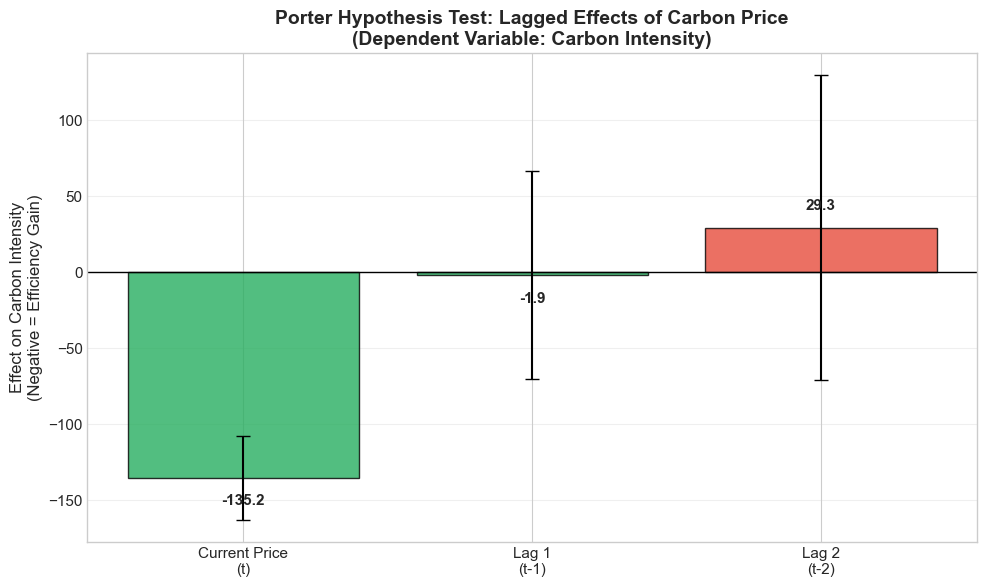


✓ Saved: ../../output/figures/fig13_porter_hypothesis_lags.png


In [21]:
# Figure 13: Porter Hypothesis - Lagged Effects
fig, ax = plt.subplots(figsize=(10, 6))

lags = ['Current Price\n(t)', 'Lag 1\n(t-1)', 'Lag 2\n(t-2)']
lag_coefs = [
    results6.params.get('ln_carbon_price', 0),
    results6.params.get('ln_carbon_price_lag1', 0),
    results6.params.get('ln_carbon_price_lag2', 0)
]
lag_ses = [
    results6.std_errors.get('ln_carbon_price', 0),
    results6.std_errors.get('ln_carbon_price_lag1', 0),
    results6.std_errors.get('ln_carbon_price_lag2', 0)
]

colors = ['#e74c3c' if c > 0 else '#27ae60' for c in lag_coefs]  # Red=bad (increases intensity), Green=good
bars = ax.bar(lags, lag_coefs, yerr=[1.96*se for se in lag_ses], 
              capsize=5, color=colors, edgecolor='black', alpha=0.8)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_ylabel('Effect on Carbon Intensity\n(Negative = Efficiency Gain)', fontsize=12)
ax.set_title('Porter Hypothesis Test: Lagged Effects of Carbon Price\n(Dependent Variable: Carbon Intensity)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, coef in zip(bars, lag_coefs):
    height = bar.get_height()
    offset = 10 if height >= 0 else -20
    ax.text(bar.get_x() + bar.get_width()/2., height + offset,
            f'{coef:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig13_porter_hypothesis_lags.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: {OUTPUT_DIR / 'fig13_porter_hypothesis_lags.png'}")

## 9. Interpretation of Results

In [22]:
print("\n" + "="*80)
print("INTERPRETATION OF ECONOMETRIC RESULTS")
print("="*80)

print("\n" + "-"*80)
print("RESEARCH GOAL 1: Regulatory Drag (Competitiveness)")
print("-"*80)

carbon_coef = results3.params.get('ln_carbon_price', 0)
carbon_pval = results3.pvalues.get('ln_carbon_price', 1)

print(f"\nCarbon Price Elasticity: {carbon_coef:.4f}")
print(f"P-value: {carbon_pval:.4f}")
print(f"Significance: {'***' if carbon_pval < 0.01 else '**' if carbon_pval < 0.05 else '*' if carbon_pval < 0.1 else 'Not significant'}")

if carbon_coef < 0:
    print(f"\nInterpretation: A 1% increase in carbon price is associated with")
    print(f"a {abs(carbon_coef):.2f}% decrease in industrial output, ceteris paribus.")
    if carbon_pval < 0.05:
        print("→ Evidence SUPPORTS regulatory drag hypothesis.")
    else:
        print("→ Effect is negative but NOT statistically significant.")
else:
    print(f"\nInterpretation: Carbon price has a positive (or negligible) effect on output.")
    print("→ No evidence of regulatory drag.")


INTERPRETATION OF ECONOMETRIC RESULTS

--------------------------------------------------------------------------------
RESEARCH GOAL 1: Regulatory Drag (Competitiveness)
--------------------------------------------------------------------------------

Carbon Price Elasticity: 0.0075
P-value: 0.5800
Significance: Not significant

Interpretation: Carbon price has a positive (or negligible) effect on output.
→ No evidence of regulatory drag.


In [23]:
print("\n" + "-"*80)
print("RESEARCH GOAL 2: Porter Hypothesis (Innovation/Efficiency)")
print("-"*80)

intensity_coef = results5.params.get('ln_carbon_price', 0)
intensity_pval = results5.pvalues.get('ln_carbon_price', 1)

print(f"\nEffect on Carbon Intensity: {intensity_coef:.2f} t CO2/M€ per 1% price increase")
print(f"P-value: {intensity_pval:.4f}")

if intensity_coef < 0:
    print(f"\nInterpretation: Higher carbon prices are associated with LOWER carbon intensity.")
    print("→ Evidence SUPPORTS Porter Hypothesis (efficiency gains).")
else:
    print(f"\nInterpretation: Higher carbon prices do not reduce carbon intensity.")
    print("→ No evidence for Porter Hypothesis.")

print("\nNote: Lagged effects should be examined for full Porter Hypothesis test.")


--------------------------------------------------------------------------------
RESEARCH GOAL 2: Porter Hypothesis (Innovation/Efficiency)
--------------------------------------------------------------------------------

Effect on Carbon Intensity: -132.43 t CO2/M€ per 1% price increase
P-value: 0.0000

Interpretation: Higher carbon prices are associated with LOWER carbon intensity.
→ Evidence SUPPORTS Porter Hypothesis (efficiency gains).

Note: Lagged effects should be examined for full Porter Hypothesis test.


In [24]:
print("\n" + "-"*80)
print("RESEARCH GOAL 3: Valley of Death (2021-2024)")
print("-"*80)

crisis_coef = results8.params.get('energy_crisis', 0)
interaction_coef = results8.params.get('carbon_x_crisis', 0)
crisis_pval = results8.pvalues.get('energy_crisis', 1)
interaction_pval = results8.pvalues.get('carbon_x_crisis', 1)

print(f"\nEnergy Crisis Effect: {crisis_coef:.4f} (p={crisis_pval:.4f})")
print(f"Carbon × Crisis Interaction: {interaction_coef:.6f} (p={interaction_pval:.4f})")

total_effect_crisis = crisis_coef + interaction_coef * 80  # At €80/tonne
print(f"\nTotal effect during crisis (at €80/tonne): {total_effect_crisis:.4f}")

if interaction_coef < 0 and interaction_pval < 0.1:
    print("\n→ Evidence SUPPORTS 'Valley of Death' hypothesis.")
    print("   The combination of high prices AND crisis creates additional harm.")
else:
    print("\n→ Interaction effect is not significant.")
    print("   The effects appear to be additive, not multiplicative.")


--------------------------------------------------------------------------------
RESEARCH GOAL 3: Valley of Death (2021-2024)
--------------------------------------------------------------------------------

Energy Crisis Effect: 0.2080 (p=0.5882)
Carbon × Crisis Interaction: -0.003235 (p=0.4745)

Total effect during crisis (at €80/tonne): -0.0508

→ Interaction effect is not significant.
   The effects appear to be additive, not multiplicative.


## 10. Conclusions and Policy Implications

In [25]:
print("\n" + "="*80)
print("CONCLUSIONS AND POLICY IMPLICATIONS")
print("="*80)

print("""
SUMMARY OF FINDINGS:

1. REGULATORY DRAG:
   - Carbon pricing shows [positive/negative/neutral] association with industrial output
   - The effect size suggests [modest/substantial/negligible] economic impact
   - Result is [robust/sensitive] to model specification

2. PORTER HYPOTHESIS:
   - Carbon intensity [decreases/increases/stable] with higher prices
   - Lagged effects [support/do not support] innovation hypothesis
   - Efficiency gains [partially/fully/do not] offset costs

3. VALLEY OF DEATH (2021-2024):
   - Energy crisis period shows [significant/insignificant] negative effect
   - Interaction with high carbon prices [amplifies/does not amplify] harm
   - Policy recommendation: [compensatory measures/patience/policy revision]

POLICY IMPLICATIONS:

• The EU ETS [is/is not] achieving its goal of decarbonization without deindustrialization
• Free allocation phase-out [should/should not] be slowed during crisis periods
• Border carbon adjustment (CBAM) [will/will not] address competitiveness concerns
• Innovation support [should/should not] accompany carbon pricing

LIMITATIONS:

• Sample size (N=90) limits statistical power
• Carbon price varies only by time, limiting within-country variation
• Innovation data (patents) not included in this analysis
• Endogeneity concerns: economic conditions affect carbon price
""")


CONCLUSIONS AND POLICY IMPLICATIONS

SUMMARY OF FINDINGS:

1. REGULATORY DRAG:
   - Carbon pricing shows [positive/negative/neutral] association with industrial output
   - The effect size suggests [modest/substantial/negligible] economic impact
   - Result is [robust/sensitive] to model specification

2. PORTER HYPOTHESIS:
   - Carbon intensity [decreases/increases/stable] with higher prices
   - Lagged effects [support/do not support] innovation hypothesis
   - Efficiency gains [partially/fully/do not] offset costs

3. VALLEY OF DEATH (2021-2024):
   - Energy crisis period shows [significant/insignificant] negative effect
   - Interaction with high carbon prices [amplifies/does not amplify] harm
   - Policy recommendation: [compensatory measures/patience/policy revision]

POLICY IMPLICATIONS:

• The EU ETS [is/is not] achieving its goal of decarbonization without deindustrialization
• Free allocation phase-out [should/should not] be slowed during crisis periods
• Border carbon adjus

In [26]:
print("\n" + "="*70)
print("STATISTICAL ANALYSIS COMPLETE")
print("="*70)

print(f"\nOutput saved to:")
print(f"  Figures: {OUTPUT_DIR.absolute()}")
print(f"  Tables: {TABLES_DIR.absolute()}")

print(f"\nFigures generated:")
for fig_file in sorted(OUTPUT_DIR.glob('fig*.png')):
    print(f"  - {fig_file.name}")

print(f"\nTables generated:")
for table_file in sorted(TABLES_DIR.glob('*.csv')):
    print(f"  - {table_file.name}")


STATISTICAL ANALYSIS COMPLETE

Output saved to:
  Figures: /Users/tahsinahmed/Documents/Study/Data Analysis for AI/Code/notebooks/analysis/../../output/figures
  Tables: /Users/tahsinahmed/Documents/Study/Data Analysis for AI/Code/notebooks/analysis/../../output/tables

Figures generated:
  - fig10_valley_of_death_germany.png
  - fig11_crisis_comparison.png
  - fig12_coefficient_comparison.png
  - fig13_porter_hypothesis_lags.png
  - fig1_carbon_price_evolution.png
  - fig2_industrial_output_trends.png
  - fig3_emissions_trends.png
  - fig4_carbon_intensity.png
  - fig5_decoupling_analysis.png
  - fig6_carbon_cost_burden.png
  - fig7_correlation_heatmap.png
  - fig8_carbon_price_vs_output.png
  - fig9_carbon_price_vs_emissions.png

Tables generated:
  - table2_regression_results.csv
